# 2 - Complex thing

In [68]:
#Imports
import PV_ICE
import pandas as pd
import numpy as np
import json
import os
import tqdm
import matplotlib.pyplot as plt

In [69]:
# This information helps with debugging and getting support :)
import sys, platform
print("Working on a ", platform.system(), platform.release())
print("Python version ", sys.version)
print("Pandas version ", pd.__version__)
print("PV_ICE version ", PV_ICE.__version__)

Working on a  Windows 11
Python version  3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
Pandas version  2.2.3
PV_ICE version  0.2.1.dev710+g684c1eea6.d20260402


## 1. Simplified Yield Model

In [70]:
# Load hail-induced PLR increase CDF
cdf_df = pd.read_csv("plr_increase_after_1in_hail.csv")

x = cdf_df["plr_percent_increase_peryear"].to_numpy(dtype=float)
y = cdf_df["cumulative_probability"].to_numpy(dtype=float)

# Safety checks
assert np.all(np.diff(y) >= 0), "CDF y-values must be nondecreasing"
assert y[0] >= 0 and y[-1] <= 1.0 + 1e-9, "CDF must stay within [0,1]"

# Normalize in case final point is not exactly 1
y = y / y[-1]

def sample_from_empirical_cdf(x_vals, cdf_vals, rng=None):
    """
    Inverse-CDF sampler from an empirical CDF.
    Returns one sampled PLR increase value (%/year).
    """
    if rng is None:
        rng = np.random.default_rng()
    u = rng.uniform()
    return np.interp(u, cdf_vals, x_vals)

In [71]:
# Generate shared Monte Carlo degradation scenarios
# These same degradation vectors will be used by both the simplified yield model
# and the PySAM model so the results are directly comparable.

rng = np.random.default_rng(123)

n_sims = 10000
analysis_period = 25
hail_year = 5              # example: storm happens at start of year 5
baseline_deg = 0.50        # %/year baseline degradation
p_increase = 0.57          # probability of added degradation after hail

extra_deg_samples = np.zeros(n_sims)
deg_vectors = np.full((n_sims, analysis_period), baseline_deg)

for i in range(n_sims):
    hit = rng.uniform() < p_increase
    if hit:
        delta_deg = sample_from_empirical_cdf(x, y, rng=rng)
    else:
        delta_deg = 0.0
    
    extra_deg_samples[i] = delta_deg
    deg_vectors[i, hail_year-1:] = baseline_deg + delta_deg  # hail year onward

In [72]:
import PySAM
from PySAM import Pvsamv1 as pv
from PySAM import Pvwattsv8 as pvwatts
from PySAM import Cashloan as com
from PySAM import Grid as grid
from PySAM import Utilityrate5 as ur
import PySAM.Pvsamv1Tools as pvtools
import PySAM.ResourceTools as tools

print("PySAM version ", PySAM.__version__)

PySAM version  7.1.0


In [73]:
# Load SAM Json Files
pv_model = pv.default("FlatPlatePVCommercial")
ur_model = ur.from_existing(pv_model)
grid_model = grid.from_existing(pv_model)
fin_model = com.from_existing(pv_model)

for json_file in os.listdir('PBL 1_Data'):
    # get the inputs from the JSON file
    with open( 'PBL 1_Data/' + json_file, 'r') as f:
            pv_inputs = json.load( f )
    
    # iterate through the input key-value pairs and set the module inputs
    for k, v in pv_inputs.items():
        if k != 'number_inputs':
            try:
                pv_model.value(k, v)
            except:
                try:
                    ur_model.value(k, v)
                except:
                    try:
                        grid_model.value(k, v)
                    except:
                        try:
                            fin_model.value(k, v)
                        except:
                            print("Variable not found in modules")

# grid_model = grid.from_existing(pv_model)
# ur_model = ur.from_existing(pv_model)
# fin_model = com.from_existing(pv_model)


In [74]:
# Assing Resource Weather Data
weather_file = "data/CA_weather_data.csv"
pv_model.SolarResource.solar_resource_file = weather_file

We use a simplified cohort reliability model inspired by PV ICE cohort accounting, but implemented independently to isolate the effects of intrinsic reliability and hazard-driven catastrophic failure on available capacity and lifetime value.

In [75]:
from PV_ICE.main import weibull_cdf, weibull_pdf, weibull_params

In [76]:
weibullIParams = weibull_params({39: 0.50, 42: 0.90})

f = weibull_cdf(
    weibullIParams["alpha"],
    weibullIParams["beta"]
)

years = np.arange(0, 51)
cdf = list(map(f, years))
pdf = [0] + [j - i for i, j in zip(cdf[:-1], cdf[1:])]

In [77]:
# If NOT Using PV ICE:
"""
def weibull_params_from_t50_t90(t50, t90):
    cdf1 = 0.50
    cdf2 = 0.90

    alpha = (
        np.log(-np.log(1 - cdf1)) - np.log(-np.log(1 - cdf2))
    ) / (
        np.log(t50) - np.log(t90)
    )

    beta = t50 / ((-np.log(1 - cdf1)) ** (1 / alpha))

    return alpha, beta


def weibull_cdf(t, alpha, beta):
    return 1 - np.exp(-((np.array(t) / beta) ** alpha))


def weibull_survival(t, alpha, beta):
    return 1 - weibull_cdf(t, alpha, beta)

def annual_failure_pdf(years, alpha, beta):
    cdf = weibull_cdf(years, alpha, beta)
    pdf = np.zeros_like(cdf, dtype=float)
    pdf[1:] = cdf[1:] - cdf[:-1]
    return pdf

P0 = 100  # MW
years = np.arange(0, 51)

alpha, beta = weibull_params_from_t50_t90(t50=39, t90=42)

S_rel = weibull_survival(years, alpha, beta)
pdf_rel = annual_failure_pdf(years, alpha, beta)

available_capacity = P0 * S_rel
annual_failures = P0 * pdf_rel
""";

In [78]:
P0 = 100  # MW
years = np.arange(0, 51)

# Leveraging PV ICE Functions
weibullIParams = weibull_params({39: 0.50, 42: 0.90})

f = weibull_cdf(
    weibullIParams["alpha"],
    weibullIParams["beta"]
)

cdf_rel = np.array(list(map(f, years)))
S_rel = 1 - cdf_rel

pdf_rel = np.zeros_like(cdf_rel)
pdf_rel[1:] = cdf_rel[1:] - cdf_rel[:-1]

available_capacity = P0 * S_rel
annual_failures = P0 * pdf_rel

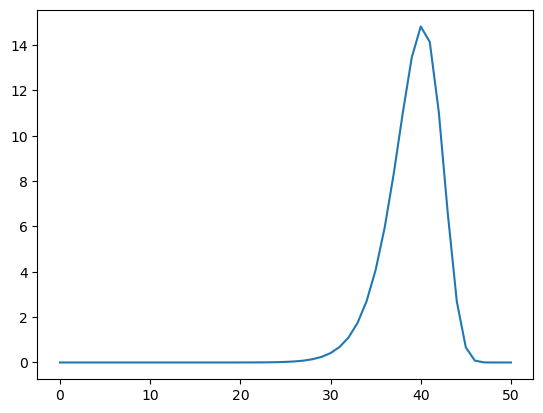

In [79]:
plt.plot(annual_failures)

Implementing the first version using the median return period as the annual event probability and the Gamma fit as the event-size distribution.

--> Confirm with Dirk whether the return-period equation should replace or refine the median return period assumption.

In [13]:
hail_return = pd.read_csv("Hail_return_period.csv")
hail_dist = pd.read_csv("Hail_size_distribution_discrete_locations.csv")

In [14]:
def get_return_period(location):
    row = hail_return[hail_return["Location"] == location]
    return float(row["return_period"].iloc[0])
    
def get_gamma_params(location):

    gamma = hail_dist[(hail_dist.Location == location) &
        (hail_dist.Distribution == "Gamma")]
    shape = float(gamma.loc[gamma.Parameter=="Shape","Estimate"].iloc[0])
    scale = float(gamma.loc[gamma.Parameter=="Scale","Estimate"].iloc[0])
    
    return shape, scale

## Spatial hail coverage modifier

### Why this is needed

The hail return-period data describe how often a hail event occurs within the geographic
area used to calculate the hazard (currently represented by the county).

However, a hailstorm does not necessarily cover the entire county.

Therefore:

**A hail event occurring in the county does not necessarily mean that the PV site is hit.**

Dirk provided an estimate of the median area covered by 2-inch hail and the area of the
county containing each study location.

For the current simplified implementation:

    coverage_fraction = median hail footprint area / county area

This is used as an additional probability that the PV site lies within the hail footprint.

Therefore, the annual probability that the PV site is hit is approximated as:

    P(site hit) = P(county hail event) × P(site within hail footprint)

or:

    P(site hit) = (1 / return_period) × coverage_fraction

### Current assumptions

- The median return period is still used to determine annual hail occurrence.
- The Gamma distribution is still used to sample hail size if the site is hit.
- The empirical conditional damage distributions are still used to sample the fraction
  of modules with broken glass.
- For now, a single median 2-inch hail footprint is used rather than sampling storm area.
- Coverage fraction is capped at 1.0 because a probability cannot exceed 100%.
- This is a first-order spatial exposure approximation. A future version can sample
  hail footprint area as a function of hail size using the provided distributions.

In [15]:
# Spatial exposure information provided by Dirk.
#
# A_total_sqmi:
#     Total area of the county containing the study location.
#
# median_hail_area_sqmi:
#     Median area covered by 2-inch hail during a hail event.
#
# coverage_fraction:
#     Approximate fraction of the county covered by the hail footprint.
#     This is used as the probability that a site located somewhere within
#     the county is inside the hail footprint when the county experiences
#     a hail event.

hail_coverage = pd.DataFrame({
    "Location": ["Austin", "Phoenix", "Denver"],
    "County": ["Travis County", "Maricopa County", "Denver County"],
    "A_total_sqmi": [1025.027, 9225.996, 154.725],
    "median_hail_area_sqmi": [208.496202, 208.496202, 208.496202]
})

# Calculate the fraction of county area covered by the median hail footprint.
hail_coverage["coverage_fraction_raw"] = (
    hail_coverage["median_hail_area_sqmi"] /
    hail_coverage["A_total_sqmi"]
)

# A probability cannot exceed 1.
# Denver's median hail footprint is larger than Denver County, so the
# simplified coverage probability is capped at 100%.
hail_coverage["coverage_fraction"] = (
    hail_coverage["coverage_fraction_raw"].clip(upper=1.0)
)

hail_coverage

,Location,County,A_total_sqmi,median_hail_area_sqmi,coverage_fraction_raw,coverage_fraction
0,Austin,Travis County,1025.027,208.496202,0.203406,0.203406
1,Phoenix,Maricopa County,9225.996,208.496202,0.022599,0.022599
2,Denver,Denver County,154.725,208.496202,1.347528,1.000000


In [16]:
def get_coverage_fraction(location):
    """
    Return the spatial hail coverage fraction for a location.

    Interpretation
    --------------
    This approximates the probability that the PV site lies inside the
    hail footprint, GIVEN that the county experiences the hail event.

    Example
    -------
    Austin coverage_fraction ≈ 0.203

    This means that, under the current simplified spatial assumption,
    approximately 20.3% of Travis County is covered by the representative
    hail footprint.

    Notes
    -----
    This is NOT the annual probability of hail.
    Annual hail occurrence is handled separately using the return period.
    """

    row = hail_coverage[hail_coverage["Location"] == location]

    if row.empty:
        raise ValueError(f"No hail coverage data found for {location}")

    return float(row["coverage_fraction"].iloc[0])

In [17]:
def get_annual_site_hail_probability(location):
    """
    Calculate the approximate annual probability that the PV site
    is directly affected by the modeled hail event.

    Step 1
    ------
    Convert the location's median return period into an annual
    county-level occurrence probability:

        P(county event) = 1 / return_period

    Step 2
    ------
    Apply the spatial coverage modifier:

        P(site hit | county event) = coverage_fraction

    Step 3
    ------
    Combine them:

        P(site hit) =
            P(county event) * P(site hit | county event)

    This is currently a simplified approximation using the median
    2-inch hail footprint.
    """

    rp = get_return_period(location)
    coverage = get_coverage_fraction(location)

    p_county_event = 1 / rp
    p_site_hit = p_county_event * coverage

    return p_site_hit

In [18]:
def hail_event(location):
    """
    Randomly determine whether the PV site is hit by hail this year.

    Returns
    -------
    True
        The simulated site experiences the modeled hail event this year.

    False
        The simulated site is not affected by hail this year.

    Important
    ---------
    This function ONLY determines whether the site is hit.

    It does NOT determine:
        - hail size
        - broken-glass fraction
        - post-hail degradation

    Those are handled later in the simulation.
    """

    p_site_hit = get_annual_site_hail_probability(location)

    return np.random.rand() < p_site_hit

In [19]:
# Event Ocurrence

'''
Replaced with functions above
county_coverage = {
    "Austin": 0.203406,2
    
    "Phoenix": 0.022599,
    "Denver": 1.0,       # capped at 1
}

def hail_event(location):
    rp = get_return_period(location)

    p_county_event = 1 / rp
    p_site_hit = p_county_event * county_coverage[location]

    return np.random.rand() < p_site_hit
'''
    
# Sample Hail-
def sample_hail(location):
    shape, scale = get_gamma_params(location)
    return np.random.gamma(shape, scale)


In [20]:
for location in ["Denver", "Phoenix", "Austin"]:

    rp = get_return_period(location)
    coverage = get_coverage_fraction(location)
    p_site = get_annual_site_hail_probability(location)

    print(f"{location}")
    print(f"  Median return period:       {rp:.1f} years")
    print(f"  County event probability:   {1/rp:.3%} per year")
    print(f"  Spatial coverage fraction:  {coverage:.3%}")
    print(f"  Site-hit probability:       {p_site:.3%} per year")
    print()

Denver
  Median return period:       9.0 years
  County event probability:   11.111% per year
  Spatial coverage fraction:  100.000%
  Site-hit probability:       11.111% per year

Phoenix
  Median return period:       16.0 years
  County event probability:   6.250% per year
  Spatial coverage fraction:  2.260%
  Site-hit probability:       0.141% per year

Austin
  Median return period:       6.0 years
  County event probability:   16.667% per year
  Spatial coverage fraction:  20.341%
  Site-hit probability:       3.390% per year



In [21]:
if hail_event("Denver"):
    hail = sample_hail("Denver")
    p_fail = fragility(hail)
else:
    p_fail = 0

In [22]:
def hail_bin_label(hail_size_in):
    if hail_size_in < 1:
        return "0_1"
    elif hail_size_in < 2:
        return "1_2"
    elif hail_size_in < 3:
        return "2_3"
    elif hail_size_in < 4:
        return "3_4"
    else:
        return "4_5"

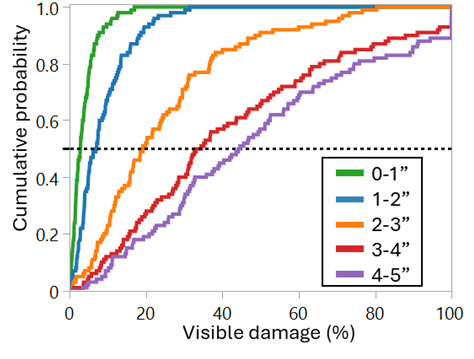

## Placeholder broken-glass damage distributions

The broken-glass damage curves used here are approximate synthetic CDFs reconstructed from the available plot of broken-glass fraction by hail-size bin. They are used only as placeholders to test the model workflow.

Final analysis should replace these curves with the original tabulated data or formally digitized curves. These curves represent conditional damage-fraction distributions:

P(Broken glass fraction ≤ x | hail-size bin)

They are not classical fragility curves; they describe the distribution of observed damage fraction for events in each hail-size bin.


In [23]:
import pandas as pd
import numpy as np

# Approximate CDF points read visually from the plot.
# x = broken glass modules (%)
# y = cumulative probability

damage_curve_points = {
    "0_1": {
        "broken_glass_percent": [0, 2, 4, 6, 8, 10, 15, 20, 100],
        "cumulative_probability": [0, 0.25, 0.55, 0.75, 0.88, 0.95, 0.99, 1.0, 1.0],
    },
    "1_2": {
        "broken_glass_percent": [0, 5, 10, 15, 20, 30, 40, 100],
        "cumulative_probability": [0, 0.25, 0.55, 0.78, 0.92, 0.99, 1.0, 1.0],
    },
    "2_3": {
        "broken_glass_percent": [0, 10, 20, 30, 40, 55, 75, 100],
        "cumulative_probability": [0, 0.15, 0.35, 0.55, 0.75, 0.88, 0.98, 1.0],
    },
    "3_4": {
        "broken_glass_percent": [0, 10, 20, 35, 50, 70, 90, 100],
        "cumulative_probability": [0, 0.10, 0.25, 0.45, 0.65, 0.80, 0.90, 1.0],
    },
    "4_5": {
        "broken_glass_percent": [0, 10, 25, 40, 60, 80, 100],
        "cumulative_probability": [0, 0.08, 0.25, 0.45, 0.68, 0.82, 0.92],
    },
}

damage_cdfs = {}

for label, data in damage_curve_points.items():
    df_curve = pd.DataFrame(data)

    # Ensure the CDF ends at 1.0. 
    # The plot suggests the 4–5" curve may not reach 1 by 100%, 
    # but for inverse-CDF sampling we need it to.
    if df_curve["cumulative_probability"].iloc[-1] < 1.0:
        df_curve.loc[len(df_curve)] = [100, 1.0]

    damage_cdfs[label] = df_curve

    filename = f"broken_glass_{label}.csv"
    df_curve.to_csv(filename, index=False)
    print(f"Saved {filename}")

Saved broken_glass_0_1.csv
Saved broken_glass_1_2.csv
Saved broken_glass_2_3.csv
Saved broken_glass_3_4.csv
Saved broken_glass_4_5.csv


In [24]:
def hail_bin_label(hail_size_in):
    if hail_size_in < 1:
        return "0_1"
    elif hail_size_in < 2:
        return "1_2"
    elif hail_size_in < 3:
        return "2_3"
    elif hail_size_in < 4:
        return "3_4"
    else:
        return "4_5"


def sample_from_empirical_cdf(cdf_df, x_col, p_col, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    x = cdf_df[x_col].to_numpy(dtype=float)
    p = cdf_df[p_col].to_numpy(dtype=float)

    order = np.argsort(p)
    p = p[order]
    x = x[order]

    u = rng.random()
    return np.interp(u, p, x)


def sample_broken_glass_fraction(hail_size_in, damage_cdfs, rng=None):
    label = hail_bin_label(hail_size_in)
    cdf_df = damage_cdfs[label]

    broken_percent = sample_from_empirical_cdf(
        cdf_df,
        x_col="broken_glass_percent",
        p_col="cumulative_probability",
        rng=rng
    )

    return broken_percent / 100.0

In [47]:
rng = np.random.default_rng(42)

hail_size = 2.4
f_cat = sample_broken_glass_fraction(hail_size, damage_cdfs, rng=rng)

print("hail size:", hail_size)
print("sampled catastrophic failure fraction:", f_cat)

hail size: 2.4
sampled catastrophic failure fraction: 0.42764159448765


In [48]:
def weibull_params_from_t50_t90(t50, t90):
    """
    Calculate Weibull shape (alpha) and scale (beta) parameters
    from t50 and t90.

    t50 = year when 50% of the original cohort has failed.
    t90 = year when 90% of the original cohort has failed.
    """
    cdf1, cdf2 = 0.50, 0.90

    alpha = (
        np.log(-np.log(1 - cdf1)) - np.log(-np.log(1 - cdf2))
    ) / (
        np.log(t50) - np.log(t90)
    )

    beta = t50 / ((-np.log(1 - cdf1)) ** (1 / alpha))

    return alpha, beta


def weibull_survival(t, alpha, beta):
    """
    Calculate Weibull survival probability at each age.

    Returns the fraction of the original cohort still surviving
    at time t from intrinsic reliability failures alone.
    """
    return np.exp(-((np.array(t) / beta) ** alpha))


def weibull_annual_failure_fraction(years, alpha, beta):
    """
    Calculate the intrinsic reliability failure fraction for each year.

    Converts Weibull survival into the fraction of modules that fail
    during each year, relative to the modules surviving at the start
    of that year.

    Returns:
        S_rel : Weibull survival fraction by year.
        f_rel : Annual failure fraction of the surviving cohort.
    """
    S_rel = weibull_survival(years, alpha, beta)

    f_rel = np.zeros_like(S_rel, dtype=float)

    for i in range(1, len(years)):
        f_rel[i] = 1.0 - S_rel[i] / S_rel[i-1]

    return S_rel, f_rel

In [49]:
def simulate_project(
    P0_MW,
    location,
    years,
    damage_cdfs,
    t50=39,
    t90=42,
    seed=0,
):
    rng = np.random.default_rng(seed)

    alpha, beta = weibull_params_from_t50_t90(t50, t90)
    S_rel_only, f_rel = weibull_annual_failure_fraction(years, alpha, beta)

    remaining_MW = P0_MW

    rows = []

    for i, year in enumerate(years):

        if i == 0:
            rows.append({
                "year": year,
                "available_capacity_MW_start": P0_MW,
                "hail_event": False,
                "hail_size_in": 0.0,
                "f_rel": 0.0,
                "f_cat": 0.0,
                "reliability_failures_MW": 0.0,
                "hail_failures_MW": 0.0,
                "total_failures_MW": 0.0,
                "available_capacity_MW_end": P0_MW,
                "S_total": 1.0,
            })
            continue

        available_start = remaining_MW

        # 1. Base intrinsic Weibull reliability failures
        rel_fail_MW = available_start * f_rel[i]
        after_rel_MW = available_start - rel_fail_MW

        # 2. Hail damage on modules that survived reliability failure
        if hail_event(location):
            hail_size = sample_hail(location)
            f_cat = sample_broken_glass_fraction(
                hail_size,
                damage_cdfs,
                rng=rng
            )
            hail_fail_MW = after_rel_MW * f_cat
            hail_bool = True
        else:
            hail_size = 0.0
            f_cat = 0.0
            hail_fail_MW = 0.0
            hail_bool = False

        total_fail_MW = rel_fail_MW + hail_fail_MW
        remaining_MW = after_rel_MW - hail_fail_MW

        rows.append({
            "year": year,
            "available_capacity_MW_start": available_start,
            "hail_event": hail_bool,
            "hail_size_in": hail_size,
            "f_rel": f_rel[i],
            "f_cat": f_cat,
            "reliability_failures_MW": rel_fail_MW,
            "hail_failures_MW": hail_fail_MW,
            "total_failures_MW": total_fail_MW,
            "available_capacity_MW_end": remaining_MW,
            "S_total": remaining_MW / P0_MW,
        })

    return pd.DataFrame(rows)

In [50]:
years = np.arange(0, 51)

res_denver = simulate_project(
    P0_MW=100,
    location="Denver",
    years=years,
    damage_cdfs=damage_cdfs,
    t50=39,
    t90=42,
    seed=42,
)

res_denver.head()

,year,available_capacity_MW_start,hail_event,hail_size_in,f_rel,f_cat,reliability_failures_MW,hail_failures_MW,total_failures_MW,available_capacity_MW_end,S_total
0,0,100.00000,False,0.000000,0.000000e+00,0.000000,0.000000e+00,0.00000,0.000000e+00,100.00000,1.000000
1,1,100.00000,True,1.017875,0.000000e+00,0.148686,0.000000e+00,14.86861,1.486861e+01,85.13139,0.851314
2,2,85.13139,False,0.000000,0.000000e+00,0.000000,0.000000e+00,0.00000,0.000000e+00,85.13139,0.851314
3,3,85.13139,False,0.000000,0.000000e+00,0.000000,0.000000e+00,0.00000,0.000000e+00,85.13139,0.851314
4,4,85.13139,False,0.000000,1.110223e-16,0.000000,9.451483e-15,0.00000,9.451483e-15,85.13139,0.851314


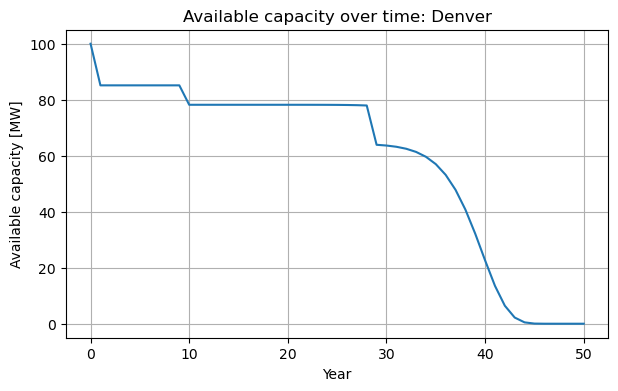

In [51]:
plt.figure(figsize=(7,4))
plt.plot(res_denver["year"], res_denver["available_capacity_MW_end"])
plt.xlabel("Year")
plt.ylabel("Available capacity [MW]")
plt.title("Available capacity over time: Denver")
plt.grid(True)
plt.show()

In [52]:
res_denver[[
    "year",
    "available_capacity_MW_start",
    "hail_event",
    "hail_size_in",
    "reliability_failures_MW",
    "hail_failures_MW",
    "total_failures_MW",
    "available_capacity_MW_end"
]]

,year,available_capacity_MW_start,hail_event,hail_size_in,reliability_failures_MW,hail_failures_MW,total_failures_MW,available_capacity_MW_end
0,0,1.000000e+02,False,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+02
1,1,1.000000e+02,True,1.017875,0.000000e+00,1.486861e+01,1.486861e+01,8.513139e+01
2,2,8.513139e+01,False,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,8.513139e+01
3,3,8.513139e+01,False,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,8.513139e+01
4,4,8.513139e+01,False,0.000000,9.451483e-15,0.000000e+00,9.451483e-15,8.513139e+01
5,5,8.513139e+01,False,0.000000,1.984811e-13,0.000000e+00,1.984811e-13,8.513139e+01
6,6,8.513139e+01,False,0.000000,3.790045e-12,0.000000e+00,3.790045e-12,8.513139e+01
7,7,8.513139e+01,False,0.000000,4.456374e-11,0.000000e+00,4.456374e-11,8.513139e+01
8,8,8.513139e+01,False,0.000000,3.738723e-10,0.000000e+00,3.738723e-10,8.513139e+01
9,9,8.513139e+01,False,0.000000,2.424844e-09,0.000000e+00,2.424844e-09,8.513139e+01


In [53]:
summary = {
    "final_capacity_MW": res_denver["available_capacity_MW_end"].iloc[-1],
    "total_reliability_failures_MW": res_denver["reliability_failures_MW"].sum(),
    "total_hail_failures_MW": res_denver["hail_failures_MW"].sum(),
    "total_failures_MW": res_denver["total_failures_MW"].sum(),
}
summary

{'final_capacity_MW': np.float64(7.681931732694953e-16),
 'total_reliability_failures_MW': np.float64(64.3425004532595),
 'total_hail_failures_MW': np.float64(35.65749954674046),
 'total_failures_MW': np.float64(99.99999999999996)}

In [54]:
## Incorporationg the PLR Decresaes now

In [55]:
plr_cdf = pd.read_csv("plr_increase_after_1in_hail.csv")
plr_cdf.columns = plr_cdf.columns.str.strip()

In [56]:
def sample_plr_increase(plr_cdf, rng=None):
    """
    Samples additional PLR after hail, in fraction/year.
    Input CSV is percent/year, so convert to fraction/year.
    """
    if rng is None:
        rng = np.random.default_rng()

    plr_percent = sample_from_empirical_cdf(
        plr_cdf,
        x_col="plr_percent_increase_peryear",
        p_col="cumulative_probability",
        rng=rng
    )

    return plr_percent / 100.0

In [57]:
def simulate_project(
    P0_MW,
    location,
    years,
    damage_cdfs,
    plr_cdf=None,
    t50=39,
    t90=42,
    seed=0,
):
    rng = np.random.default_rng(seed)

    alpha, beta = weibull_params_from_t50_t90(t50, t90)
    S_rel_only, f_rel = weibull_annual_failure_fraction(years, alpha, beta)

    remaining_MW = P0_MW
    extra_plr_per_year = 0.0
    performance_factor = 1.0

    rows = []

    for i, year in enumerate(years):

        if i == 0:
            rows.append({
                "year": year,
                "available_capacity_MW_start": P0_MW,
                "hail_event": False,
                "hail_size_in": 0.0,
                "f_rel": 0.0,
                "f_cat": 0.0,
                "plr_added_this_year": 0.0,
                "cumulative_extra_plr_per_year": 0.0,
                "performance_factor": 1.0,
                "reliability_failures_MW": 0.0,
                "hail_failures_MW": 0.0,
                "total_failures_MW": 0.0,
                "available_capacity_MW_end": P0_MW,
                "effective_capacity_MW_end": P0_MW,
                "S_total": 1.0,
            })
            continue

        available_start = remaining_MW

        # 0. Apply accumulated post-hail PLR to performance
        performance_factor *= (1.0 - extra_plr_per_year)

        # 1. Intrinsic Weibull reliability failures
        rel_fail_MW = available_start * f_rel[i]
        after_rel_MW = available_start - rel_fail_MW

        # 2. Hail event and broken-glass failures
        if hail_event(location):
            hail_size = sample_hail(location)

            f_cat = sample_broken_glass_fraction(
                hail_size,
                damage_cdfs,
                rng=rng
            )

            hail_fail_MW = after_rel_MW * f_cat
            hail_bool = True

            # 3. Post-hail degradation for survivors
            if plr_cdf is not None:
                plr_added = sample_plr_increase(plr_cdf, rng=rng)
                extra_plr_per_year += plr_added
            else:
                plr_added = 0.0

        else:
            hail_size = 0.0
            f_cat = 0.0
            hail_fail_MW = 0.0
            hail_bool = False
            plr_added = 0.0

        total_fail_MW = rel_fail_MW + hail_fail_MW
        remaining_MW = after_rel_MW - hail_fail_MW

        effective_capacity_MW = remaining_MW * performance_factor

        rows.append({
            "year": year,
            "available_capacity_MW_start": available_start,
            "hail_event": hail_bool,
            "hail_size_in": hail_size,
            "f_rel": f_rel[i],
            "f_cat": f_cat,
            "plr_added_this_year": plr_added,
            "cumulative_extra_plr_per_year": extra_plr_per_year,
            "performance_factor": performance_factor,
            "reliability_failures_MW": rel_fail_MW,
            "hail_failures_MW": hail_fail_MW,
            "total_failures_MW": total_fail_MW,
            "available_capacity_MW_end": remaining_MW,
            "effective_capacity_MW_end": effective_capacity_MW,
            "S_total": remaining_MW / P0_MW,
        })

    return pd.DataFrame(rows)

In [58]:
years = np.arange(0, 51)

res_denver = simulate_project(
    P0_MW=100,
    location="Austin",
    years=years,
    damage_cdfs=damage_cdfs,
    plr_cdf=plr_cdf,
    t50=39,
    t90=42,
    seed=42,
)

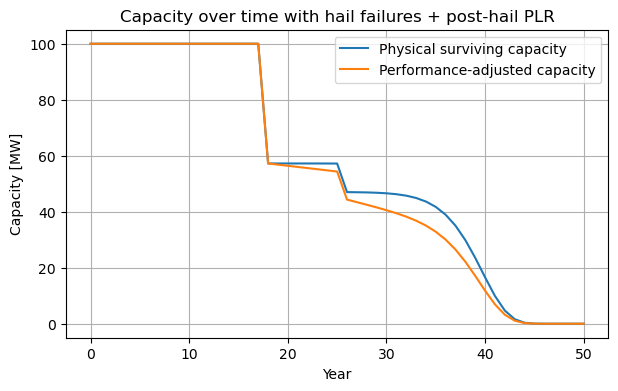

In [59]:
plt.figure(figsize=(7,4))
plt.plot(res_denver["year"], res_denver["available_capacity_MW_end"], label="Physical surviving capacity")
plt.plot(res_denver["year"], res_denver["effective_capacity_MW_end"], label="Performance-adjusted capacity")
plt.xlabel("Year")
plt.ylabel("Capacity [MW]")
plt.title("Capacity over time with hail failures + post-hail PLR")
plt.legend()
plt.grid(True)
plt.show()

## That looks quite drastic. Mini MC


In [60]:
def run_monte_carlo(
    n_sims,
    P0_MW,
    location,
    years,
    damage_cdfs,
    plr_cdf=None,
    t50=39,
    t90=42,
    base_seed=0,
):
    sims = []

    for s in range(n_sims):
        res = simulate_project(
            P0_MW=P0_MW,
            location=location,
            years=years,
            damage_cdfs=damage_cdfs,
            plr_cdf=plr_cdf,
            t50=t50,
            t90=t90,
            seed=base_seed + s,
        )
        res["sim"] = s
        sims.append(res)

    return pd.concat(sims, ignore_index=True)

In [62]:
years = np.arange(0, 51)

mc = run_monte_carlo(
    n_sims=200,
    P0_MW=100,
    location="Austin",
    years=years,
    damage_cdfs=damage_cdfs,
    plr_cdf=plr_cdf,
    t50=39,
    t90=42,
    base_seed=100,
)

In [63]:
# Summarizing by year
mc_summary = (
    mc.groupby("year")
    .agg(
        physical_p10=("available_capacity_MW_end", lambda x: np.percentile(x, 10)),
        physical_p50=("available_capacity_MW_end", lambda x: np.percentile(x, 50)),
        physical_p90=("available_capacity_MW_end", lambda x: np.percentile(x, 90)),
        effective_p10=("effective_capacity_MW_end", lambda x: np.percentile(x, 10)),
        effective_p50=("effective_capacity_MW_end", lambda x: np.percentile(x, 50)),
        effective_p90=("effective_capacity_MW_end", lambda x: np.percentile(x, 90)),
    )
    .reset_index()
)

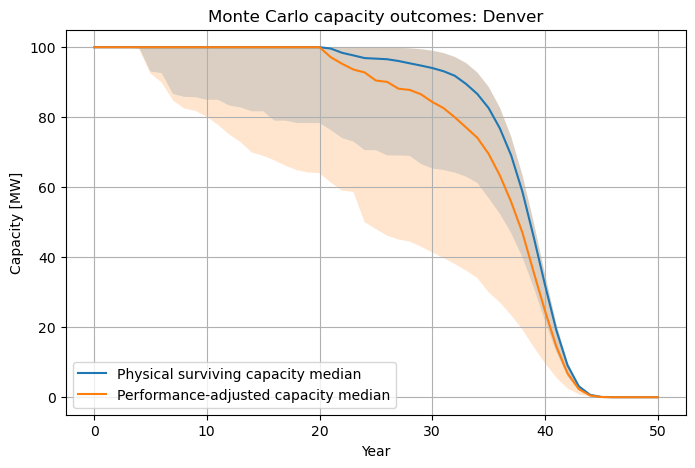

In [64]:
plt.figure(figsize=(8,5))

plt.plot(mc_summary["year"], mc_summary["physical_p50"], label="Physical surviving capacity median")
plt.fill_between(
    mc_summary["year"],
    mc_summary["physical_p10"],
    mc_summary["physical_p90"],
    alpha=0.2
)

plt.plot(mc_summary["year"], mc_summary["effective_p50"], label="Performance-adjusted capacity median")
plt.fill_between(
    mc_summary["year"],
    mc_summary["effective_p10"],
    mc_summary["effective_p90"],
    alpha=0.2
)

plt.xlabel("Year")
plt.ylabel("Capacity [MW]")
plt.title("Monte Carlo capacity outcomes: Denver")
plt.legend()
plt.grid(True)
plt.show()

In [65]:
final_year = mc[mc["year"] == years[-1]]

final_year[[
    "available_capacity_MW_end",
    "effective_capacity_MW_end",
    "S_total"
]].describe(percentiles=[0.1, 0.5, 0.9])

,available_capacity_MW_end,effective_capacity_MW_end,S_total
count,2.000000e+02,2.000000e+02,2.000000e+02
mean,1.148961e-15,8.522920e-16,1.148961e-17
std,2.681360e-16,4.255489e-16,2.681360e-18
min,3.333774e-17,6.216562e-18,3.333774e-19
10%,7.766009e-16,2.468991e-16,7.766009e-18
50%,1.219862e-15,8.456462e-16,1.219862e-17
90%,1.403506e-15,1.403506e-15,1.403506e-17
max,1.403506e-15,1.403506e-15,1.403506e-17


In [66]:
hail_counts = (
    mc.groupby("sim")["hail_event"]
    .sum()
    .reset_index(name="n_hail_years")
)

hail_counts.describe(percentiles=[0.1, 0.5, 0.9])

,sim,n_hail_years
count,200.000000,200.000000
mean,99.500000,1.640000
std,57.879185,1.348887
min,0.000000,0.000000
10%,19.900000,0.000000
50%,99.500000,2.000000
90%,179.100000,4.000000
max,199.000000,6.000000


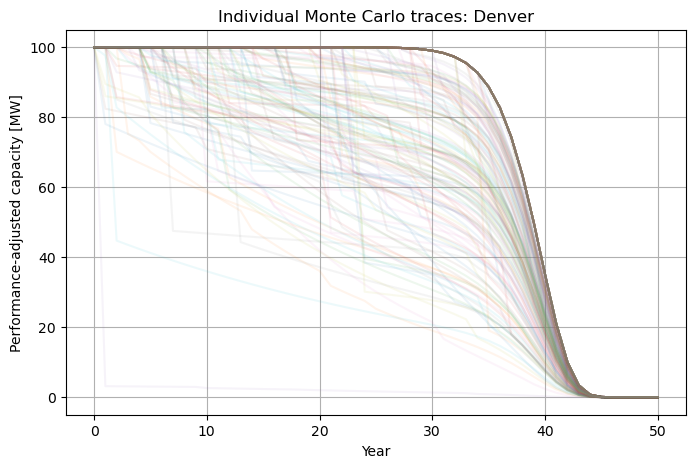

In [67]:
plt.figure(figsize=(8,5))

for sim, g in mc.groupby("sim"):
    plt.plot(g["year"], g["effective_capacity_MW_end"], alpha=0.08)

plt.xlabel("Year")
plt.ylabel("Performance-adjusted capacity [MW]")
plt.title("Individual Monte Carlo traces: Denver")
plt.grid(True)
plt.show()

## FIxing that Im applyign the PLR to all, also variuos times??

In [ ]:
#Reliability failures apply to all physically surviving capacity.
#Hail broken-glass failures remove part of the surviving capacity.
#Post-hail PLR applies only to the capacity that survived that hail event.
#Optionally: each MW only gets the hail PLR penalty once, even if more hail events occur later.
#if apply_plr_once=True, future hail can still break modules, but it does **not add another PLR penalty to already damaged survivors.

def simulate_project(
    P0_MW,
    location,
    years,
    damage_cdfs,
    plr_cdf=None,
    t50=39,
    t90=42,
    seed=0,
    apply_plr_once=True,
):
    rng = np.random.default_rng(seed)

    alpha, beta = weibull_params_from_t50_t90(t50, t90)
    S_rel_only, f_rel = weibull_annual_failure_fraction(years, alpha, beta)

    # Physical capacity buckets
    undamaged_MW = P0_MW
    hail_damaged_MW = 0.0

    # Performance factor for the hail-damaged survivor bucket only
    hail_damaged_perf_factor = 1.0
    extra_plr_per_year = 0.0

    rows = []

    for i, year in enumerate(years):

        if i == 0:
            rows.append({
                "year": year,
                "hail_event": False,
                "hail_size_in": 0.0,
                "f_rel": 0.0,
                "f_cat": 0.0,
                "plr_added_this_year": 0.0,
                "cumulative_extra_plr_per_year": 0.0,
                "undamaged_MW_end": undamaged_MW,
                "hail_damaged_MW_end": hail_damaged_MW,
                "available_capacity_MW_end": P0_MW,
                "effective_capacity_MW_end": P0_MW,
                "reliability_failures_MW": 0.0,
                "hail_failures_MW": 0.0,
                "total_failures_MW": 0.0,
                "S_total": 1.0,
            })
            continue

        available_start = undamaged_MW + hail_damaged_MW

        # Apply existing PLR penalty only to hail-damaged survivor bucket
        hail_damaged_perf_factor *= (1.0 - extra_plr_per_year)

        # 1. Intrinsic Weibull reliability failures applied proportionally to both buckets
        rel_fail_undamaged = undamaged_MW * f_rel[i]
        rel_fail_damaged = hail_damaged_MW * f_rel[i]
        rel_fail_MW = rel_fail_undamaged + rel_fail_damaged

        undamaged_MW -= rel_fail_undamaged
        hail_damaged_MW -= rel_fail_damaged

        # 2. Hail event
        hail_bool = False
        hail_size = 0.0
        f_cat = 0.0
        hail_fail_MW = 0.0
        plr_added = 0.0

        if hail_event(location):
            hail_bool = True
            hail_size = sample_hail(location)

            f_cat = sample_broken_glass_fraction(
                hail_size,
                damage_cdfs,
                rng=rng
            )

            # Broken glass failures apply to both buckets
            hail_fail_undamaged = undamaged_MW * f_cat
            hail_fail_damaged = hail_damaged_MW * f_cat
            hail_fail_MW = hail_fail_undamaged + hail_fail_damaged

            undamaged_survivors_after_hail = undamaged_MW - hail_fail_undamaged
            damaged_survivors_after_hail = hail_damaged_MW - hail_fail_damaged

            # 3. Post-hail PLR assignment
            if plr_cdf is not None:
                plr_added = sample_plr_increase(plr_cdf, rng=rng)

                if apply_plr_once:
                    # Only modules that were previously undamaged and survived this hail
                    # move into the hail-damaged bucket.
                    newly_damaged_MW = undamaged_survivors_after_hail

                    undamaged_MW = 0.0
                    hail_damaged_MW = damaged_survivors_after_hail + newly_damaged_MW

                    # If this is the first time any modules become hail-damaged, 
                    # add one PLR penalty. Do not stack future PLR penalties.
                    if extra_plr_per_year == 0.0:
                        extra_plr_per_year = plr_added
                    else:
                        plr_added = 0.0

                else:
                    # Allow PLR penalties to stack across hail events
                    undamaged_MW = 0.0
                    hail_damaged_MW = damaged_survivors_after_hail + undamaged_survivors_after_hail
                    extra_plr_per_year += plr_added

            else:
                # No PLR consequence; survivors stay in their buckets
                undamaged_MW = undamaged_survivors_after_hail
                hail_damaged_MW = damaged_survivors_after_hail

        total_fail_MW = rel_fail_MW + hail_fail_MW
        available_end = undamaged_MW + hail_damaged_MW

        # Effective capacity = undamaged full performance + damaged reduced performance
        effective_capacity_MW = undamaged_MW + hail_damaged_MW * hail_damaged_perf_factor

        rows.append({
            "year": year,
            "hail_event": hail_bool,
            "hail_size_in": hail_size,
            "f_rel": f_rel[i],
            "f_cat": f_cat,
            "plr_added_this_year": plr_added,
            "cumulative_extra_plr_per_year": extra_plr_per_year,
            "undamaged_MW_end": undamaged_MW,
            "hail_damaged_MW_end": hail_damaged_MW,
            "available_capacity_MW_end": available_end,
            "effective_capacity_MW_end": effective_capacity_MW,
            "reliability_failures_MW": rel_fail_MW,
            "hail_failures_MW": hail_fail_MW,
            "total_failures_MW": total_fail_MW,
            "S_total": available_end / P0_MW,
        })

    return pd.DataFrame(rows)

In [ ]:
def run_monte_carlo(
    n_sims,
    P0_MW,
    location,
    years,
    damage_cdfs,
    plr_cdf=None,
    t50=39,
    t90=42,
    base_seed=0,
    apply_plr_once=True,

):
    sims = []

    for s in range(n_sims):
        res = simulate_project(
            P0_MW=P0_MW,
            location=location,
            years=years,
            damage_cdfs=damage_cdfs,
            plr_cdf=plr_cdf,
            t50=t50,
            t90=t90,
            seed=base_seed + s,
            apply_plr_once=apply_plr_once,

        )
        res["sim"] = s
        sims.append(res)

    return pd.concat(sims, ignore_index=True)

In [ ]:
years = np.arange(0, 51)

mc = run_monte_carlo(
    n_sims=200,
    P0_MW=100,
    location="Denver",
    years=years,
    damage_cdfs=damage_cdfs,
    plr_cdf=plr_cdf,
    t50=39,
    t90=42,
    base_seed=100,
)

In [ ]:
# Summarizing by year
mc_summary = (
    mc.groupby("year")
    .agg(
        physical_p10=("available_capacity_MW_end", lambda x: np.percentile(x, 10)),
        physical_p50=("available_capacity_MW_end", lambda x: np.percentile(x, 50)),
        physical_p90=("available_capacity_MW_end", lambda x: np.percentile(x, 90)),
        effective_p10=("effective_capacity_MW_end", lambda x: np.percentile(x, 10)),
        effective_p50=("effective_capacity_MW_end", lambda x: np.percentile(x, 50)),
        effective_p90=("effective_capacity_MW_end", lambda x: np.percentile(x, 90)),
    )
    .reset_index()
)

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(mc_summary["year"], mc_summary["physical_p50"], label="Physical surviving capacity median")
plt.fill_between(
    mc_summary["year"],
    mc_summary["physical_p10"],
    mc_summary["physical_p90"],
    alpha=0.2
)

plt.plot(mc_summary["year"], mc_summary["effective_p50"], label="Performance-adjusted capacity median")
plt.fill_between(
    mc_summary["year"],
    mc_summary["effective_p10"],
    mc_summary["effective_p90"],
    alpha=0.2
)

plt.xlabel("Year")
plt.ylabel("Capacity [MW]")
plt.title("Monte Carlo capacity outcomes: Denver")
plt.legend()
plt.grid(True)
plt.show()

# Comparing between sities now

In [ ]:
locations = ["Phoenix", "Austin"]

mc_results = {}

for loc in locations:
    mc_results[loc] = run_monte_carlo(
        n_sims=200,
        P0_MW=100,
        location=loc,
        years=years,
        damage_cdfs=damage_cdfs,
        plr_cdf=plr_cdf,
        t50=39,
        t90=42,
        base_seed=100,
        apply_plr_once=True,
    )

In [ ]:
summaries = {}

for loc, mc in mc_results.items():

    summaries[loc] = (
        mc.groupby("year")
          .agg(
              p10=("effective_capacity_MW_end",
                   lambda x: np.percentile(x,10)),
              median=("effective_capacity_MW_end",
                      "median"),
              p90=("effective_capacity_MW_end",
                   lambda x: np.percentile(x,90)),
          )
          .reset_index()
    )

In [ ]:
plt.figure(figsize=(8,5))

colors = {
    "Phoenix":"tab:green",
    "Austin":"tab:orange"
}

for loc in locations:

    s = summaries[loc]

    plt.plot(
        s["year"],
        s["median"],
        lw=2,
        label=loc,
        color=colors[loc]
    )

    plt.fill_between(
        s["year"],
        s["p10"],
        s["p90"],
        alpha=0.15,
        color=colors[loc]
    )

plt.xlabel("Year")
plt.ylabel("Effective Capacity (MW)")
plt.title("Monte Carlo Comparison of Project Capacity")
plt.grid(alpha=0.3)
plt.legend(title="Location")
plt.tight_layout()

In [ ]:
plt.figure(figsize=(7,4))

for loc in locations:

    final = mc_results[loc]
    final = final[final.year==30]

    plt.hist(
        final["effective_capacity_MW_end"],
        bins=20,
        alpha=0.4,
        label=loc
    )

plt.xlabel("Remaining Effective Capacity (MW)")
plt.ylabel("Monte Carlo Realizations")
plt.legend()
plt.tight_layout()

In [ ]:
for loc in ["Phoenix", "Austin"]:
    final = mc_results[loc]
    final = final[final.year == 30]

    print(f"\n{loc}")
    print(final["effective_capacity_MW_end"].describe(
        percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]
    ))

# Apply to PYSAM

In [ ]:
def run_one_pysam_case(deg_vector):
    # Pick a config that matches your base case
    # Example placeholder:
    m = pv.default("FlatPlatePVSingleOwner")
    m.SolarResource.solar_resource_file = weather_file
    # You must already have a known-good base model or exported JSON inputs
    # loaded here. If you already have a SAM case, using exported inputs is best.

    m.Lifetime.system_use_lifetime_output = 1
    m.Lifetime.analysis_period = len(deg_vector)
    m.Lifetime.dc_degradation = list(deg_vector)

    # Optional but often useful
    m.Lifetime.save_full_lifetime_variables = 1

    m.execute()

    # Choose outputs you care about; exact output names depend on model setup
    # Commonly inspect:
    outputs = m.Outputs.export()

    return outputs

In [ ]:
# Number of degradation scenarios to evaluate with PySAM.
# Currently set to reuse the same vectors generated above from the simplified method
# Becuase of this, n_sims_pySAM should be be smaller than n_sims, and can be very small while testing to reduce runtime.
n_sims_pySAM = 5
lifetime_metric = []

if n_sims_pySAM > n_sims:
    raise ValueError(
        f"n_sims_pySAM ({n_sims_pySAM}) cannot exceed the number of "
        f"generated degradation scenarios ({n_sims})."
    )

for i in tqdm.tqdm(range(n_sims_pySAM), desc="Running PySAM Monte Carlo"):
    # THIS Would regenerate the degradation vectors; calling the previously generate dones from the simplified model
    #hit = rng.uniform() < p_increase
    #delta_deg = sample_from_empirical_cdf(x, y, rng) if hit else 0.0
    #deg_vec = np.full(analysis_period, baseline_deg)
    #deg_vec[hail_year-1:] = baseline_deg + delta_deg

    deg_vec = deg_vectors[i]
    out = run_one_pysam_case(deg_vec)

    total_gen = np.sum(out["gen"])   # one scalar only
    lifetime_metric.append(total_gen)

In [ ]:
arr = np.array(lifetime_metric, dtype=float)

print("N =", len(arr))
print("P50 =", np.percentile(arr, 50))
print("P90 =", np.percentile(arr, 10))
print("P95 =", np.percentile(arr, 5))
print("Mean =", arr.mean())
print("Std =", arr.std())

import matplotlib.pyplot as plt

p50 = np.percentile(arr, 50)
p90 = np.percentile(arr, 10)

plt.figure(figsize=(7,5))
plt.hist(arr, bins=40)
plt.axvline(p50, linestyle="--", label=f"P50 = {p50:.2f}")
plt.axvline(p90, linestyle="--", label=f"P90 = {p90:.2f}")
plt.xlabel("Lifetime generation")
plt.ylabel("Count")
plt.title("PySAM Monte Carlo Results")
plt.legend()
plt.tight_layout()
plt.show()

### Sanity check - Selecting the appropriate PySAM output

Initially, the Monte Carlo results were evaluated using the `annual_energy` output, but this metric did not change between degradation scenarios. The following checks verify that the degradation vectors are correctly propagated through the PySAM simulation and identify which output is appropriate for quantifying lifetime energy uncertainty.

Two extreme degradation scenarios (no degradation vs. severe degradation after Year 4) are simulated to confirm that the model responds to changes in the degradation profile. The `annual_energy` output is first compared between the two cases and then the relevant PySAM outputs are inspected to determine which variables are sensitive to lifetime degradation.

These tests showed that `annual_energy` remained unchanged, whereas the time-series generation output (`gen`) varied between scenarios. Consequently, the lifetime generation, computed as `np.sum(gen)`, was selected as the metric for the Monte Carlo analysis.

In [ ]:
# Generating two EXTREME test case, not realistic ones
deg_vec_A = [0.0] * 25  # No degradation ever
deg_vec_B = [0.0]*4 + [10.0]*21  # Absurd degradation after year 4

out_A = run_one_pysam_case(deg_vec_A)
out_B = run_one_pysam_case(deg_vec_B)

print("annual_energy A:", out_A.get("annual_energy"))
print("annual_energy B:", out_B.get("annual_energy"))

In [ ]:
# Checking which outputs actually exist. 
keys = sorted(out_A.keys())
for k in keys:
    if any(s in k.lower() for s in ["annual", "gen", "energy", "lifetime", "cf"]):
        print(k, type(out_A[k]))

In [ ]:
# Checking which outputs actually change
deg_vec_A = [0.0] * 25
deg_vec_B = [0.0]*4 + [10.0]*21

out_A = run_one_pysam_case(deg_vec_A)
out_B = run_one_pysam_case(deg_vec_B)

for k in sorted(out_A.keys()):
    if any(s in k.lower() for s in ["gen", "energy", "lifetime", "cf"]):
        a = out_A[k]
        b = out_B[k]
        try:
            print(k, type(a), len(a), np.allclose(np.array(a), np.array(b)))
        except:
            print(k, type(a), a, b, a == b)